<div style='text-align: right; font-size: 16px;'>
<br/>
<img src="images/HWR_logo.svg" alt="drawing" width="30%"/>
<br/>
Fachbereich Duales Studium Wirtschaft • Technik<br/>
ET1031 Mathematische Grundlagen III (Signale und Systeme)<br/>
Prof. Dr. Luis Fernando Ferreira Furtado, Berlin, 16.08.2026<br/>
</div>

# Kapitel 1. Übersicht

In [1]:
# Defaults
layout_default_kwargs = {"width": 1000, "height": 400}

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 1.1
__Digitales Faltungsfilter__
<br/>
Ein digitaler Faltungsfilter ist ein System, das eine Faltungssumme der Systemimpulsantwort ℎ[𝑛] mit dem Eingangssignal 𝑥[𝑛] implementiert, um ein gefiltertes Ausgangssignal 𝑦[𝑛] zu erhalten.


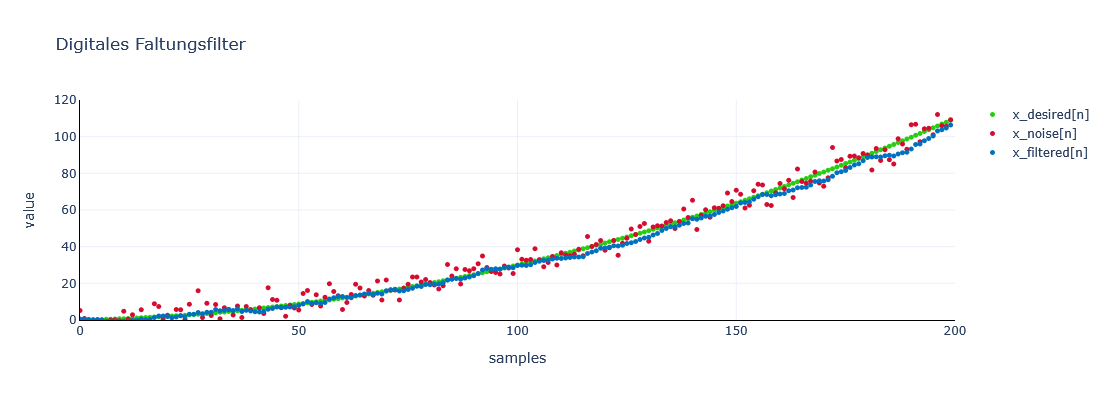

In [2]:
import numpy as np
import plotly.graph_objects as go

# Define the impulse response (Filter)
#h = [3/6, 2/6, 1/6]
#h = [0.4, 0.3, 0.2, 0.1]
#h = np.ones(10)/10
h = [0.11, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

# Define a time axis and a random signal as example
samples = 200
t = np.arange(0, samples) # Time in seconds
x_desired = (t/(samples/10)) + (t/(samples/10))**2 # Desired signal
x_noise = x_desired + np.random.normal(0, 4, size=len(t)) # Noisy signal

# Execute the convolutional sum (fiter the noise signal)
x_filtered = np.convolve(x_noise, h)[:samples]

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=x_desired, name='x_desired[n]', mode='markers', marker=dict(size=5, color="#28CC12")))
fig.add_trace(go.Scatter(x=t, y=x_noise, name='x_noise[n]', mode='markers', marker=dict(size=5, color='#D50C2F')))
fig.add_trace(go.Scatter(x=t, y=x_filtered, name='x_filtered[n]', mode='markers', marker=dict(size=5, color='#0070C0')))

fig.update_layout(
    xaxis_title='samples',
    yaxis_title='value',
    template='plotly_white',
    xaxis_range=[0,samples], yaxis_range=[0,120],
    title=dict(text='Digitales Faltungsfilter'),
    **layout_default_kwargs
)

fig.update_xaxes(showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showline=True, linewidth=1, linecolor='black')

fig.show()



<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 1.2
__Beispiel eines digitalen Filters__
<br/>
Während der Pandemiezeit war es schwierig, die Infektionswellen nur mit täglichen Daten zu erkennen. Eine rollierende Summe von 7 Tagen wurde verwendet, um die Daten zu „filtern“ und eine leichter zu erkennende Grafik zu erstellen. <br><br>
Daten-Quelle: obert Koch-Institut https://zenodo.org/records/13358115



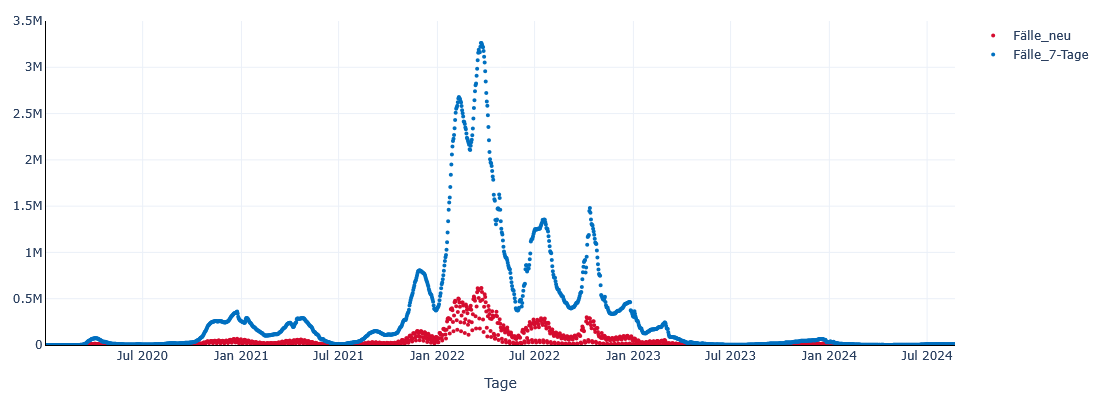

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Read the csv data
df = pd.read_csv('data/COVID-19-Faelle_7-Tage-Inzidenz_Deutschland.csv', usecols=['Meldedatum', 'Faelle_neu'])

# Sum the daily data
df = df.groupby('Meldedatum').sum().reset_index()

# Define the impulse response (7 Tage Rolling Sum)
h = [1, 1, 1, 1, 1, 1, 1]

# Execute the convolutional sum (fiter the noise signal)
df['Faelle_7-Tage'] = np.convolve(df['Faelle_neu'], h)[:len(df['Faelle_neu'])]

# Plot (time-domain)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Meldedatum'], y=df['Faelle_neu'], mode='markers', marker=dict(size=4, color='#D50C2F'), name='Fälle_neu'))
fig.add_trace(go.Scatter(x=df['Meldedatum'], y=df['Faelle_7-Tage'], mode='markers', marker=dict(size=4, color='#0070C0'), name='Fälle_7-Tage'))
fig.update_layout(
    template='plotly_white',
    xaxis = dict(title_text='Tage'),
    margin=dict(l=20, r=20, t=20, b=20),
    yaxis_range=[0,3.5E6],
    xaxis_range=["2020-01-03","2024-08-22"],
    **layout_default_kwargs
)

axes_kwargs = {
    "showline": True,
    "linewidth": 1,
    "linecolor": "black"
}
fig.update_xaxes(**axes_kwargs)
fig.update_yaxes(**axes_kwargs)

fig.show()

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 1.3
__Impulswahlverfahren vs Mehrfrequenzwahlverfahren__
<br/>
- Die Impulswahlverfahren und Mehrfrequenzwahlverfahren (MFV) – DTMF auf Englisch (Dual-Tone Multi-Frequency) – sind zwei Verfahren, die in Telefonsystemen zur Übertragung von gewählten Nummern verwendet werden.
- Bei der Impulswahl wird jede Ziffer durch eine Reihe von elektrischen Impulsen dargestellt, während bei MFV für jede Ziffer bestimmte Töne verwendet werden. 
- Die MFV generiert ein Signal, das zwei oszillierende Signale mit unterschiedlichen Frequenzen summiert, eines für die Spalte und eines für die Zeile der ausgewählten Zahl.

| |1209 Hz|1336 Hz|1477 Hz|
|-:|:-:|:-:|:-:|
| __697 Hz__ |1|2|3|
| __770 Hz__ |4|5|6|
| __852 Hz__ |7|8|9|
| __941 Hz__ |*|0|#|

In [4]:
from IPython.display import Audio, display
import numpy as np
import pandas as pd
import plotly.express as px
from ipywidgets import interact

# Definition of a function that calculates the signals and displays the audio players and graphics
def make_sound(button):

    # Define a dictionary to store the frequencies of each button
    btn_freq = {
        1: [697, 1209], # button: [column, row]
        2: [697, 1336], # button: [column, row]
        3: [697, 1477], # button: [column, row]
        4: [770, 1209], # button: [column, row]
        5: [770, 1336], # button: [column, row]
        6: [770, 1477], # button: [column, row]
        7: [852, 1209], # button: [column, row]
        8: [852, 1336], # button: [column, row]
        9: [852, 1477], # button: [column, row]
        0: [941, 1336]  # button: [column, row]
    }

    # Sampling configuration
    sampling_rate = 44100 # Sampling rate (Hz)
    seconds = 3           # Seconds to be recorded
    samples = sampling_rate * seconds # Samples
    amp = 15E3 # amplitude must be between -32767 and 32767 (16 bits)
    t=np.arange(samples)

    # Calculate the signals
    x_row = amp*np.sin(2 * np.pi * btn_freq[button][0] * t / sampling_rate)
    x_column = amp*np.sin(2 * np.pi * btn_freq[button][1] * t / sampling_rate)
    y = x_column + x_row

    # Display sounds
    print('Button:', button)
    display(Audio(y, rate=sampling_rate))
    print('Row:', btn_freq[button][0], 'Hz')
    display(Audio(x_row, rate=sampling_rate))
    print('Column:', btn_freq[button][1], 'Hz')
    display(Audio(x_column, rate=sampling_rate))

    # Plot (time-domain)
    x_max = int(0.02 * sampling_rate) + 1
    df = pd.DataFrame({
        'time [s]':t[:x_max]/sampling_rate,
        'y':y[:x_max],
        'x_row':x_row[:x_max],
        'x_column':x_column[:x_max],
    })
    fig = px.line(
        df,
        x='time [s]',
        y=['y', 'x_row', 'x_column'],
        title='Button '+str(button),
        template='plotly_white',
        range_y=[-2*amp, 2*amp]
    )
    fig.update_layout(
        xaxis_title='time [s]',
        yaxis_title='amplitude',
        **layout_default_kwargs
    )
    fig.show()

    # Plot (frequency-domain)
    fig = px.scatter(template='plotly_white', range_x=[0, 1500], range_y=[0, amp], opacity=0)
    fig.update_layout(
        xaxis_title='frequency [Hz]',
        yaxis_title='amplitude',
        **layout_default_kwargs
    )

    vline_kwargs = { "line_width": 0.5, "line_dash": "dash", "line_color": "#EF553B" }
    for freq in [697, 770, 852, 941]:
        fig.add_vline(x=freq, **vline_kwargs)
    fig.add_vline(x=btn_freq[button][0], line_width=3, line_color='#EF553B')

    vline_kwargs["line_color"] = "#00CC96"
    for freq in [1209, 1336, 1477]:
        fig.add_vline(x=freq, **vline_kwargs)
    fig.add_vline(x=btn_freq[button][1], line_width=3, line_color='#00CC96')
    fig.show()

# Execute the defined function with the DropBox intera
# ction
interact(make_sound, button=range(10));

interactive(children=(Dropdown(description='button', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9), value=0), Output(…